In [2]:
import glob
import json
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import figure_styles

In [7]:

DEPTHS = [2, 4, 6, 8]
NUM_FILES = 10
WEIGHTS = [5, 4]
GRAPH_NAME = "N40R3R_"
PROBLEMS = ["MIS_", "MC_"]
PROBLEM_TITLES = ["MIS", "MaxCut"]
PARAMS = ["energy"]

METHOD_LEGEND_TITLE = "Parameter setting method"
EVALUATION_LEGEND_TITLE = "Energy evaluation method"
OUTPUT_FILE = "comparison_MIS_MaxCut_R3R_PP.pdf"


GRAPH_REPO = "../data/training/random_regular"

PP_METHODS = [
    ("TQA*", "TQA"),
    ("Fixed Angles*", "FA"),
    ("INTERP", "I"),
    ("Fourier", "F"),
]

In [14]:
missing_reports: list[str] = []


def load_json_by_partial_name(
    partial_name: str,
    directory: str | Path = ".",
    report_missing: bool = True,
) -> tuple[dict | None, bool]:
    """Return ``(data, True)`` for the newest matching JSON file, else ``(None, False)``."""
    pattern = os.path.join(str(directory), f"*{partial_name}*.json")
    matches = glob.glob(pattern)
    if not matches:
        if report_missing:
            missing_reports.append(f"No JSON files matching: {partial_name} (in {directory})")
        return None, False
    try:
        latest = max(
            matches,
            key=lambda s: int(m.group()) if (m := re.search(r"(\d+)(?=\.json$)", s)) else -1,
        )
    except (TypeError, ValueError):
        latest = matches[0]
    with open(latest) as f:
        return json.load(f), True


def nan_array(shape: tuple[int, ...]) -> np.ndarray:
    values = np.empty(shape)
    values.fill(np.nan)
    return values


def nested_energy(data: dict | None, *keys: str) -> float:
    """Read a nested energy value from a JSON payload, returning NaN when unavailable."""
    if data is None:
        return np.nan
    current = data
    for key in keys:
        if not isinstance(current, dict) or key not in current:
            return np.nan
        current = current[key]
    try:
        return float(current)
    except (TypeError, ValueError):
        return np.nan


def load_pp_results() -> dict[str, np.ndarray]:
    shape = (NUM_FILES, len(DEPTHS), len(PARAMS), len(PROBLEMS))
    results = {method_label: nan_array(shape) for method_label, _ in PP_METHODS}

    for problem_index, problem in enumerate(PROBLEMS):
        weight = WEIGHTS[problem_index]
        for graph_index in range(NUM_FILES):
            prefix = f"00{graph_index}{GRAPH_NAME}{problem}"

            data_i_pp, _ = load_json_by_partial_name(
                f"{prefix}I_PP_optMW{weight}",
                directory=GRAPH_REPO,
            )
            data_f_pp, _ = load_json_by_partial_name(
                f"{prefix}F_PP_optMW{weight}",
                directory=GRAPH_REPO,
            )

            for depth_index, depth in enumerate(DEPTHS):
                data_tqa_pp, _ = load_json_by_partial_name(
                    f"{prefix}TQA_PP_optMW{weight}_{depth}",
                    directory=GRAPH_REPO,
                )
                data_fa_pp, _ = load_json_by_partial_name(
                    f"{prefix}FA_PP_optMW{weight}_{depth}",
                    directory=GRAPH_REPO,
                )

                for param_index, param in enumerate(PARAMS):
                    results["TQA*"][graph_index, depth_index, param_index, problem_index] = nested_energy(
                        data_tqa_pp,
                        "1",
                        param,
                    )
                    results["Fixed Angles*"][graph_index, depth_index, param_index, problem_index] = nested_energy(
                        data_fa_pp,
                        "1",
                        param,
                    )
                    results["INTERP"][graph_index, depth_index, param_index, problem_index] = nested_energy(
                        data_i_pp,
                        "2",
                        str(depth),
                        param,
                    )
                    results["Fourier"][graph_index, depth_index, param_index, problem_index] = nested_energy(
                        data_f_pp,
                        "2",
                        str(depth),
                        param,
                    )

    return results


def mean_std_by_depth(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        means = np.nanmean(values, axis=0)
        stds = np.nanstd(values, axis=0)
    return means, stds


def add_legends(fig: plt.Figure, axs) -> None:
    method_legend_items = [
        ("Fourier", "Fourier"),
        ("Fixed Angles*", "Fixed Angles*"),
        ("INTERP", "INTERP"),
        ("TQA*", "TQA*"),
    ]
    method_handles = [
        figure_styles.method_legend_handle(
            figure_styles.format_method_label(label),
            method,
        )
        for label, method in method_legend_items
    ]
    evaluation_handles = [
        figure_styles.evaluation_legend_handle("PP", "PP"),
    ]

    axs[0].legend(
        handles=method_handles,
        # title=METHOD_LEGEND_TITLE,
        **figure_styles.method_legend_kwargs(),
    )
    # fig.legend(
    #     handles=evaluation_handles,
    #     title=EVALUATION_LEGEND_TITLE,
    #     **figure_styles.evaluation_legend_kwargs(bbox_to_anchor=(0.85, -0.03), ncol=1),
    # )


def main() -> None:
    results = load_pp_results()

    if missing_reports:
        print("Missing files (plot will use available data only):")
        for message in missing_reports:
            print(" ", message)

    figure_styles.apply_rcparams()
    fig, axs = plt.subplots(
        2,
        1,
        dpi=figure_styles.FIGURE_DPI,
        figsize=figure_styles.figsize(aspect_ratio=0.8),
    )

    for problem_index, ax in enumerate(axs):
        for method_label, _ in PP_METHODS:
            means, stds = mean_std_by_depth(results[method_label][:, :, 0, problem_index])
            if np.all(np.isnan(means)):
                continue
            ax.errorbar(
                DEPTHS,
                means,
                yerr=stds,
                label=figure_styles.format_method_label(method_label),
                **figure_styles.style_errorbar(method_label, "PP"),
            )
        # ax.set_title(PROBLEM_TITLES[problem_index])
        ax.set_xticks(DEPTHS)
    axs[1].set_xlabel("Depth")
    axs[0].set_ylabel("Energy")
    axs[1].set_ylabel("Energy")

    figure_styles.add_panel_labels(axs, labels=("(a) MIS", "(b) MaxCut"))
    add_legends(fig, axs)
    figure_styles.adjust_subplots_for_legend(fig, bottom=0.22, wspace=0.1)
    
    axs[1].set_yticks([12, 16, 20])
    fig.show()



(a) MIS
(b) MaxCut


/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_66817/731358856.py:180: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


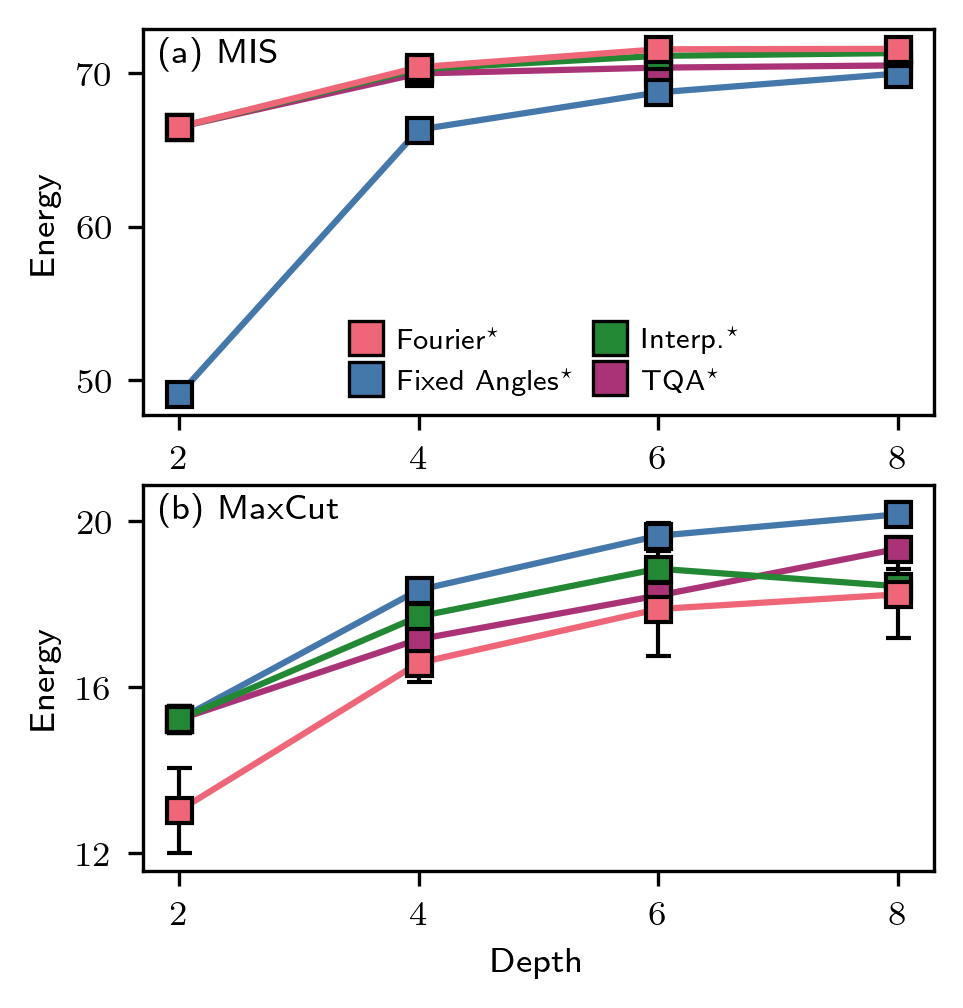

In [15]:
main()